In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -----------------------------
# Load final processed CSV
# -----------------------------
CSV = Path("../../data/gravity/Onyx_Profile_DEM_Elevations_LiDAR_Corrected.csv")
df = pd.read_csv(CSV)

OUT = Path("../../figures/Final_figures")
OUT.mkdir(exist_ok=True)

x = df["station"].astype(float)

def rel(y):
    """Plot values relative to their own mean so processing stages compare clearly."""
    return y - np.nanmean(y)

def detrend(y, x=x):
    """Remove best-fit linear regional trend."""
    p = np.polyfit(x, y, 1)
    return y - np.polyval(p, x)

df

,station,lat,lon,elev_m,grav_mean,grav_dc,grav_rel,FAC,FAA,instrument,...,gps_minus_dem_fixed_m,elevation_m_original,elevation_m_fixed_dem,height_above_reference_m,bouguer_correction_mgal,gravity_simple_bouguer_corrected_mgal,elev_m_original,lon_original_gps,lat_original_gps,elev_m_original_gps
0,1.0,40.478700,-106.835500,2111.5461,3891.8183,3891.8184,0.0162,0.495071,651.9238,41422,...,0.921857,2112.468,2111.5461,1.604248,0.179601,0.331670,2111.5461,-106.8355,40.4787,2111.5461
1,3.0,40.478714,-106.835507,2111.4756,3891.8427,3891.8428,0.0406,0.473297,651.6708,41422,...,0.093414,2111.569,2111.4756,1.533691,0.171702,0.342196,2111.4756,-106.8355,40.4787,2111.4756
2,4.0,40.478721,-106.835511,2111.4346,3891.8650,3891.8652,0.0630,0.460640,651.7311,41422,...,0.257430,2111.692,2111.4346,1.492676,0.167110,0.356530,2111.4346,-106.8355,40.4787,2111.4346
3,5.0,40.478729,-106.835514,2111.3806,3891.8853,3891.8855,0.0833,0.443989,651.8040,41422,...,0.481385,2111.862,2111.3806,1.438721,0.161069,0.366220,2111.3806,-106.8355,40.4787,2111.3806
4,6.0,40.478736,-106.835518,2111.3364,3891.8993,3891.8996,0.0974,0.430352,651.7958,41422,...,0.453574,2111.790,2111.3364,1.394531,0.156122,0.371630,2111.3364,-106.8355,40.4787,2111.3364
5,7.0,40.478743,-106.835521,2111.2737,3891.9140,3891.9143,0.1121,0.410990,651.6549,41422,...,0.012318,2111.286,2111.2737,1.331787,0.149098,0.373992,2111.2737,-106.8355,40.4787,2111.2737
6,8.0,40.478750,-106.835525,2111.2446,3891.9357,3891.9360,0.1338,0.402024,651.6353,41422,...,-0.092629,2111.152,2111.2446,1.302734,0.145845,0.389979,2111.2446,-106.8355,40.4787,2111.2446
7,9.0,40.478757,-106.835529,2111.2625,3891.9553,3891.9557,0.1535,0.407524,651.6738,41422,...,-0.049451,2111.213,2111.2625,1.320557,0.147840,0.413183,2111.2625,-106.8355,40.4787,2111.2625
8,10.0,40.478764,-106.835532,2111.2550,3891.9743,3891.9747,0.1725,0.405188,651.6737,41422,...,-0.103883,2111.151,2111.2550,1.312988,0.146993,0.430695,2111.2550,-106.8355,40.4787,2111.2550
9,11.0,40.478771,-106.835536,2111.1765,3891.9880,3891.9884,0.1862,0.381003,651.6460,41422,...,-0.159514,2111.017,2111.1765,1.234619,0.138219,0.428984,2111.1765,-106.8355,40.4788,2111.1765


KeyError: 'gravity_free_air_only_mgal'

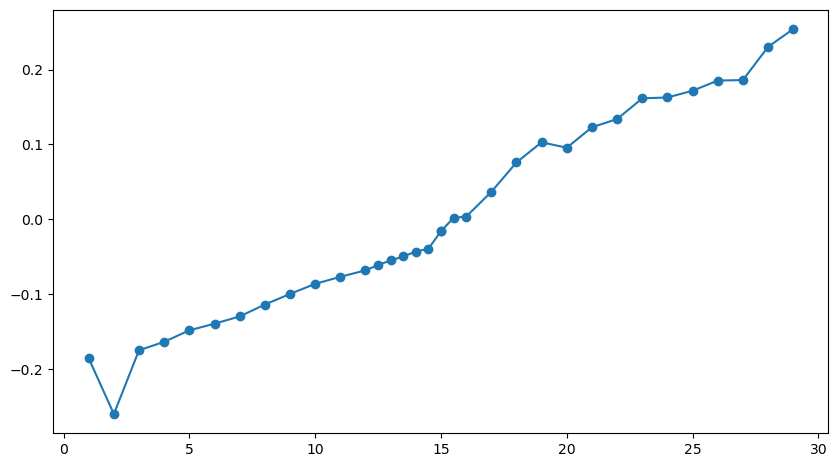

In [4]:
# -----------------------------
# Figure 1: Processing stages, normalized
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["gravity_tied_mgal"]), "o-", label="Drift + instrument tied")
plt.plot(x, rel(df["gravity_free_air_only_mgal"]), "o-", label="Free-air corrected")
plt.plot(x, rel(df["gravity_harmonica_lidar_corrected_mgal"]), "o-", label="LiDAR terrain corrected")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Gravity relative to line mean (mGal)")
#plt.title("Gravity Processing Stages")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
#plt.savefig(OUT / "Grav_01_processing_stages_relative.png", dpi=300)
plt.show()



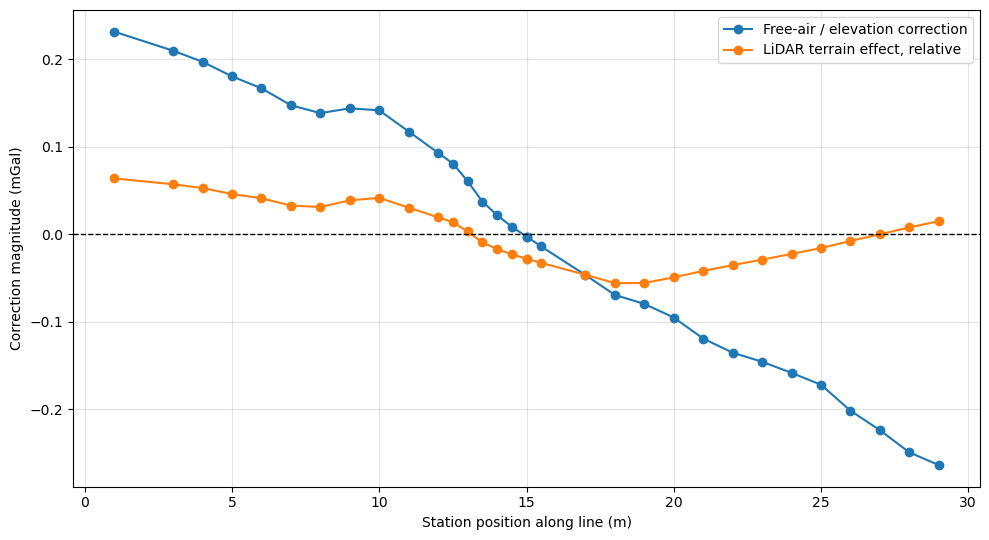

In [6]:
# -----------------------------
# Figure 2: Correction terms only
# -----------------------------
plt.figure(figsize=(10, 5.5))

plt.plot(x, rel(df["free_air_correction_mgal"]), "o-", label="Free-air / elevation correction")
plt.plot(x, df["harmonica_gz_relative_mgal"], "o-", label="LiDAR terrain effect, relative")

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station position along line (m)")
plt.ylabel("Correction magnitude (mGal)")
#plt.title("Elevation and LiDAR Terrain Correction Terms")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUT / "Grav_02_Elev_LiDAR_Corrections.png", dpi=300)
plt.show()



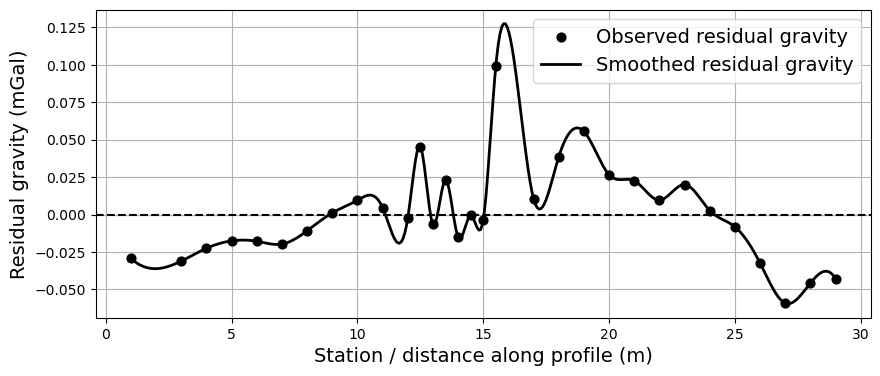

In [6]:
# # -----------------------------
# # Figure 3: Final residual anomaly after removing regional trend
# # -----------------------------
# final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
# resid = detrend(final)

# plt.figure(figsize=(10, 5.5))
# plt.plot(x, resid, "ko-", label="Final LiDAR-corrected residual")

# # highlight likely mine-shaft anomaly zone
# plt.axvspan(12, 13.5, alpha=0.2, label="Primary negative anomaly zone")

# plt.axhline(0, color="k", linestyle="--", linewidth=1)
# plt.xlabel("Station position along line (m)")
# plt.ylabel("Detrended residual gravity (mGal)")
# #plt.title("Final Residual Gravity Anomaly")
# plt.legend()
# plt.grid(True, alpha=0.35)
# plt.tight_layout()
# plt.savefig(OUT / "Grav_03_final_residual_anomaly.png", dpi=300)
# plt.show()

from scipy.interpolate import make_interp_spline

# -----------------------------
# Figure 3: Final residual anomaly after removing regional trend
# -----------------------------
final = df["gravity_harmonica_lidar_corrected_mgal"].astype(float)
resid = detrend(final)

# Put x and residual into one dataframe
plot_df = pd.DataFrame({
    "x": x,
    "resid": resid
})

# Sort and average duplicate station positions
plot_df = (
    plot_df
    .groupby("x", as_index=False)
    .mean()
    .sort_values("x")
)

x_plot = plot_df["x"].to_numpy()
resid_plot = plot_df["resid"].to_numpy()

# Smooth curve
x_smooth = np.linspace(x_plot.min(), x_plot.max(), 400)
spline = make_interp_spline(x_plot, resid_plot, k=3)
resid_smooth = spline(x_smooth)

plt.figure(figsize=(10,4))
plt.axhline(0, color="k", linestyle="--")

# Observed points
plt.scatter(
    x_plot,
    resid_plot,
    color="black",
    s=40,
    label="Observed residual gravity",
    zorder=3
)

# Smoothed curve
plt.plot(
    x_smooth,
    resid_smooth,
    color="black",
    linewidth=2,
    label="Smoothed residual gravity",
)

# Highlight anomaly zone
# plt.axvspan(
#     12,
#     13.5,
#     color="red",
#     alpha=0.20,
#     label="Primary Negative Anomaly Zone"
# )

plt.xlabel("Station / distance along profile (m)", fontsize=14)
plt.ylabel("Residual gravity (mGal)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=14)

plt.savefig(
    OUT / "Grav_03_final_residual_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

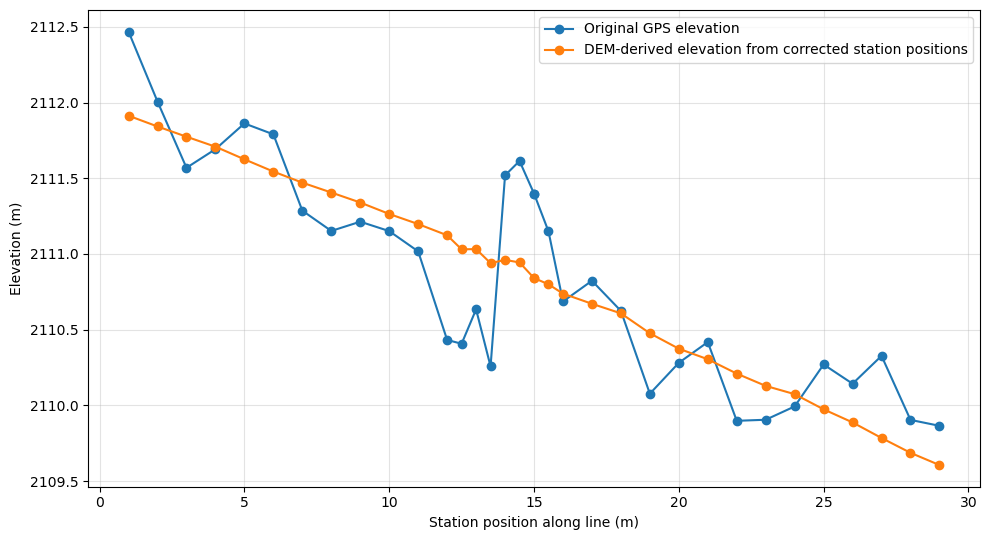

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../../data/gravity/Onyx_Gravity_LiDAR_Terrain_Corrected.csv"
)

df = df.sort_values("station")

plt.figure(figsize=(10,5.5))

plt.plot(
    df["station"],
    df["gps_elevation_m"],
    "o-",
    label="Original GPS elevation"
)

plt.plot(
    df["station"],
    df["dem_elevation_m_at_station"],
    "o-",
    label="DEM-derived elevation from corrected station positions"
)

plt.xlabel("Station position along line (m)")
plt.ylabel("Elevation (m)")
#plt.title("GPS Elevation vs Corrected DEM-Derived Elevation")

plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUT / "Grav_Elevations_GPS_DEM.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()